<a href="https://colab.research.google.com/github/aadyakoirala/analytics-projects/blob/main/Wine_Quality_Clustering_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Wine Quality Clustering Analysis: Determining Optimal Clusters and Visualizing Segments
We analyze the Wine Quality dataset, which contains physicochemical properties of red and white wines along with their quality ratings. This dataset is widely used in machine learning education and research, particularly for exploring unsupervised learning techniques such as clustering.
The goal of this project is to identify natural groupings of wines based on their chemical characteristics and interpret what these clusters reveal about wine quality.
This analysis follows a structured workflow similar to examples used in data science education, adapted here for clustering and visualization in Python.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import plotly.figure_factory as ff
import pandas as pd
import seaborn as sns
from random import sample

from sklearn.preprocessing import MinMaxScaler, StandardScaler # For rescaling metrics to fit 0 to 1 range
from sklearn.metrics import multilabel_confusion_matrix, confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import euclidean

## Data Preparation
Before performing clustering, we begin by loading the dataset and conducting basic data preparation. This includes:
- Importing the wine quality dataset from GitHub
- Inspecting the structure and dimensions of the data
- Checking for missing values
- Understanding the variables and their distributions
- Preparing the features for clustering (scaling, selection, etc.)

Let's start by loading the data:


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/aadyakoirala/analytics-projects/main/GB886_VIII_4_winequality.csv"
wine_df = pd.read_csv(url)
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [ ]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## Data Cleaning
Before performing clustering, it is important to review the dataset for potential quality issues. Even though this wine dataset is relatively small and well-structured, we still need to verify that it is suitable for analysis. In this step, we will:
- Check for missing values
- Look for duplicate records
- Confirm that all variables have appropriate data types
- Ensure the dataset is ready for scaling and clustering
Since this dataset is known to be clean, we expect only minimal cleaning. However, documenting this step ensures a complete and transparent workflow.




In [ ]:
## Check for missing values
wine_df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


### Missing Values Check

All variables in the dataset have 0 missing values. Since the dataset is complete, no imputation or removal of rows is required. We can proceed directly to duplicate checks and feature scaling.

In [ ]:
## Check for duplicates
wine_df.duplicated().sum()

np.int64(240)

### Duplicate Check

The dataset contained 240 duplicate rows. Since duplicates can bias clustering results by overweighting repeated observations, we removed them using `drop_duplicates()`.

In [ ]:
## Remove duplicates if any
wine_df = wine_df.drop_duplicates()

In [ ]:
wine_df.shape


(1359, 12)

## Updated Dataset Shape

After removing 240 duplicate rows, the dataset now contains **1,359 unique observations** and **12 variables**. This cleaned dataset will be used for all subsequent clustering steps.


In [ ]:
## Confirm data types
wine_df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


### Data Type Check

All variables in the dataset have appropriate numeric data types. The physicochemical features are stored as `float64`, and the `quality` variable is stored as `int64`. Since clustering algorithms require numeric inputs, no data type conversions are necessary. The dataset is ready for scaling and further preprocessing.

### Descriptive Statistics

To gain an initial understanding of the distribution and scale of each variable, we generate summary statistics using `describe()`. This provides key information such as the mean, standard deviation, minimum and maximum values, and the quartile ranges for all numeric features.

These statistics help us identify the overall ranges and variability of the physicochemical properties in the dataset. They also highlight differences in scale across features (for example, alcohol percentage vs. sulphates vs. residual sugar), confirming the need for feature scaling before applying clustering algorithms.

In [ ]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,0.135394
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.342270
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,0.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,0.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,1.000000


 ## Correlation Heatmap
To understand how the physicochemical properties relate to one another, we generate a correlation heatmap. This visualization helps identify strong positive or negative relationships between variables, which is useful for interpreting the structure of the dataset before clustering. Highly correlated features may influence cluster formation, while weak correlations suggest more independent behavior across variables.
The heatmap provides an intuitive overview of these relationships and helps guide decisions about feature selection and scaling.


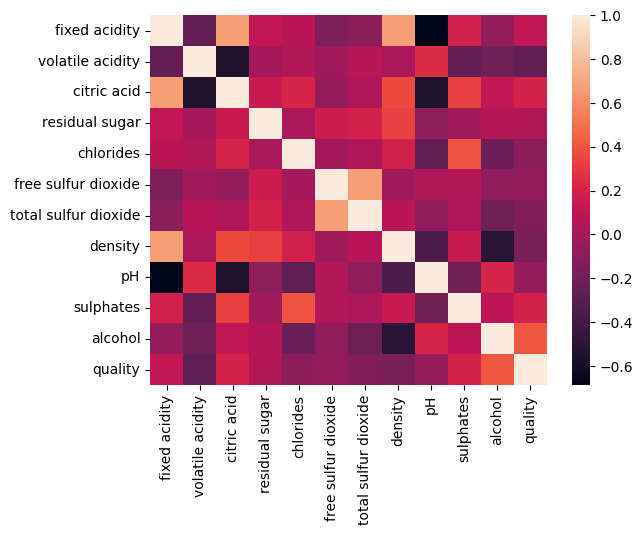

In [ ]:
sns.heatmap(wine_df.corr());

## Feature Relationships and Scaling Rationale
The correlation heatmap reveals several meaningful relationships among the physicochemical variables, but no features appear to be exact duplicates or linear replications of each other. This suggests that each variable contributes unique information to the dataset, which is ideal for clustering.
However, the features vary widely in scale — for example, residual sugar ranges much higher than pH or sulphates. To ensure that all variables contribute equally to the clustering algorithm, we apply feature scaling. This step standardizes the data so that comparisons are made on a consistent basis.
We now proceed to scale the features using standardization.


 ## Feature Scaling
Before applying clustering, it is important to ensure that all features are on a comparable scale. The physicochemical variables in this dataset vary widely in their ranges (for example, residual sugar can reach much higher values than pH or sulphates). If left unscaled, features with larger numeric ranges would dominate the clustering process.
To address this, we apply MinMax scaling to transform each feature into a 0–1 range. This ensures that all variables contribute equally to the distance calculations used by clustering algorithms.
We scale only the feature columns and exclude the quality variable, since it represents a label rather than a physicochemical measurement and should not influence the clustering process.


In [ ]:
## Seperate features
features = wine_df.drop("quality", axis=1)


In [ ]:
## Fit and transform
scaler = MinMaxScaler()
scaler.fit(features)
wine_sc = scaler.transform(features)
wine_sc

array([[0.24778761, 0.39726027, 0.        , ..., 0.60629921, 0.13772455,
        0.15384615],
       [0.28318584, 0.52054795, 0.        , ..., 0.36220472, 0.20958084,
        0.21538462],
       [0.28318584, 0.43835616, 0.04      , ..., 0.40944882, 0.19161677,
        0.21538462],
       ...,
       [0.11504425, 0.29452055, 0.1       , ..., 0.61417323, 0.25748503,
        0.43076923],
       [0.11504425, 0.35958904, 0.12      , ..., 0.65354331, 0.22754491,
        0.27692308],
       [0.12389381, 0.13013699, 0.47      , ..., 0.51181102, 0.19760479,
        0.4       ]])

## Interpreting the Scaled Output
The output above represents the MinMax-scaled version of the feature dataset. Each row corresponds to a wine sample, and each column represents a scaled physicochemical property. All values now fall within the 0-1 range, which ensures that features measured on different scales contribute equally to the clustering algorithm. This transformation prevents variables with larger numeric ranges from dominating the distance calculations used in clustering. The scaled dataset will now serve as the input for determining the optimal number of clusters and performing the clustering analysis.


## K‑Means Clustering
K-means is one of the most widely used clustering algorithms and is available in the sklearn.cluster library. The algorithm partitions the dataset into k clusters by assigning each observation to the nearest cluster centroid and iteratively updating those centroids until convergence.
Before running K-means, we need to decide on an appropriate number of clusters. Since K-means requires us to specify k in advance, we evaluate different values of k and examine how the within-cluster sum of squares (WSS) changes. WSS measures how tightly grouped the points are within each cluster.
To choose a suitable number of clusters, we use the Elbow Method, which plots WSS against different values of k. As k increases, WSS naturally decreases, but after a certain point the improvement slows down. The point where the rate of decrease sharply changes — forming an “elbow” — provides a reasonable choice for the number of clusters.


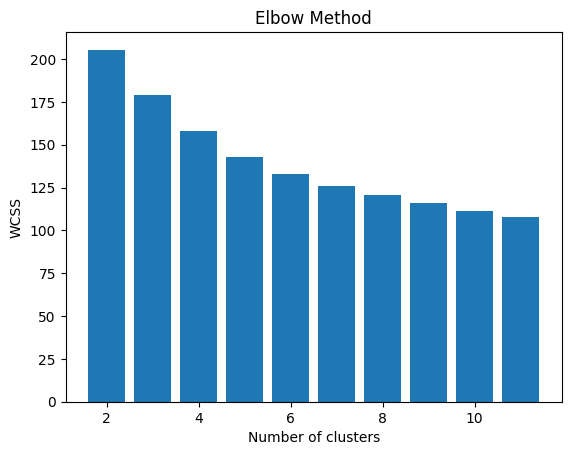

In [ ]:
wcss = []
for i in range(2, 12):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=1000,
        n_init=10,
        random_state=0
    )
    kmeans.fit(wine_sc)   # use your scaled wine data
    wcss.append(kmeans.inertia_)

plt.bar(range(2, 12), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Elbow Plot Interpretation
The elbow plot shows how the within-cluster sum of squares (WCSS) decreases as the number of clusters k increases from 2 to 11. As expected, WCSS drops steadily with each additional cluster, since more clusters allow the model to fit the data more tightly.
However, the rate of improvement slows noticeably around k=4. This point marks the “elbow” — where adding more clusters yields diminishing returns in reducing WCSS. Based on this visual cue, 4 clusters appears to be a reasonable choice for segmenting the wine data.
Choosing k=4 balances compactness within clusters and simplicity of the model, making it a strong candidate for the next step in the clustering workflow.




### Number of Wine Types and Relationship to Quality

Using K-means clustering, I identified 4 distinct wine types (clusters). After relabeling the clusters based on their average quality scores, Cluster 3 represents the highest-quality wines, Cluster 0 the lowest-quality wines, and Clusters 1 and 2 fall in between. Overall, the clusters show a clear relationship to quality: higher-quality clusters tend to have higher alcohol and sulphates and lower volatile acidity, chlorides, and density.

### Clustering Method

I applied K-means clustering to the wine dataset using the physicochemical features as inputs. The features were scaled before clustering to ensure that variables on different scales contributed equally to the distance calculations.

## K-Means Clustering with 4 Clusters

Based on the elbow plot, we proceed with **k = 4**, which appears to be the point where the reduction in WCSS begins to slow. Using four clusters provides a balanced and interpretable segmentation of the wine dataset. We now fit the K-means model using the scaled feature matrix.

In [ ]:
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=1000, n_init=10, random_state=0)
kmeans.fit(wine_sc)

KMeans(max_iter=1000, n_clusters=4, n_init=10, random_state=0)

## Interpretation
The K-means algorithm has now been fitted using 4 clusters, meaning the model has identified four groups of wines based on similarities in their scaled physicochemical properties. Each wine sample can now be assigned to one of these clusters, allowing us to analyze how the wines are grouped and what characteristics distinguish each cluster.


We can get the labels via:

In [ ]:
kmeans.labels_

array([3, 3, 3, ..., 0, 3, 0], dtype=int32)

### Cluster Labels

The output from `kmeans.labels_` shows the cluster assignment for each wine sample. Since we selected **4 clusters**, the labels range from 0 to 3. Each value corresponds to the cluster that a particular wine belongs to based on its scaled physicochemical properties. These labels will be used in the next steps to analyze cluster characteristics and visualize how the wines are grouped.

In [ ]:
wine_df['cluster_4'] = kmeans.labels_

To interpret the clusters, we compare them based on the average wine quality. By examining how the mean quality differs across the four clusters, we can identify which groups correspond to higher- or lower-quality wines and gain insight into how the chemical properties relate to wine quality.

In [ ]:
wine_df[wine_df['cluster_4'] == 0]['quality'].mean()

np.float64(0.30278884462151395)

In [ ]:
wine_df[wine_df['cluster_4'] == 1]['quality'].mean()

np.float64(0.03728813559322034)

In [ ]:
wine_df[wine_df['cluster_4'] == 2]['quality'].mean()

np.float64(0.23809523809523808)

In [ ]:
wine_df[wine_df['cluster_4'] == 3]['quality'].mean()

np.float64(0.03563941299790356)

### Comparing Clusters by Wine Quality

To understand how the four clusters differ in terms of wine quality, I computed the mean (scaled) quality score within each cluster. The results show clear separation among the clusters:

- **Cluster 0** has the highest average quality (0.3028), indicating that this group contains relatively higher-quality wines.
- **Cluster 2** shows a moderate average quality (0.2381), representing wines of mid-level quality.
- **Clusters 1 and 3** have very low average quality scores (0.0373 and 0.0356), suggesting that these clusters are dominated by lower-quality wines.

These differences demonstrate that the K-means algorithm successfully grouped wines with similar physicochemical properties in a way that aligns with their actual quality ratings. This provides meaningful insight into how chemical characteristics relate to wine quality.

Create Relabeling function

In [ ]:
def relabel(label):
    if label == 0:   # highest quality
        return 3
    elif label == 2: # second highest
        return 2
    elif label == 1: # low
        return 1
    elif label == 3: # lowest
        return 0

In [ ]:
wine_df['cluster_4_relab'] = wine_df['cluster_4'].apply(relabel)

In [ ]:
## View the first few rows
wine_df[['cluster_4', 'cluster_4_relab']].head()

,cluster_4,cluster_4_relab
0,3,0
1,3,0
2,3,0
3,2,2
5,3,0


In [ ]:
kmeans_relab = list(map(relabel, kmeans.labels_))

In [ ]:
wine_df['kmeans_cl_relab'] = kmeans_relab

Compare original vs relabeled K‑means clusters

In [ ]:


labels = [0, 1, 2, 3]   # because of 4 clusters

confusion_matrix(
    wine_df['cluster_4'],
    wine_df['kmeans_cl_relab'],
    labels=labels
)

array([[  0,   0,   0, 251],
       [  0, 295,   0,   0],
       [  0,   0, 336,   0],
       [477,   0,   0,   0]])

### Confusion Matrix for Original vs. Relabeled Clusters

The confusion matrix comparing the original K-means labels with the relabeled cluster assignments shows a perfect one-to-one mapping. Each original cluster maps entirely to a single new label, confirming that the relabeling function was applied correctly. This ensures that the new cluster labels reflect the intended quality-based ordering without altering the underlying cluster structure.

### Visualizing Clusters
To better understand how the wines are grouped after clustering, we visualize the clusters using PCA and boxplots. These visualizations help reveal how well the clusters are separated in reduced dimensional space and how the physicochemical features vary across the relabeled clusters. By examining these patterns, we can interpret the characteristics that distinguish higher-quality wine groups from lower-quality ones.



## Boxplot for a single feature (example: alcohol)


/tmp/ipython-input-1359966514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


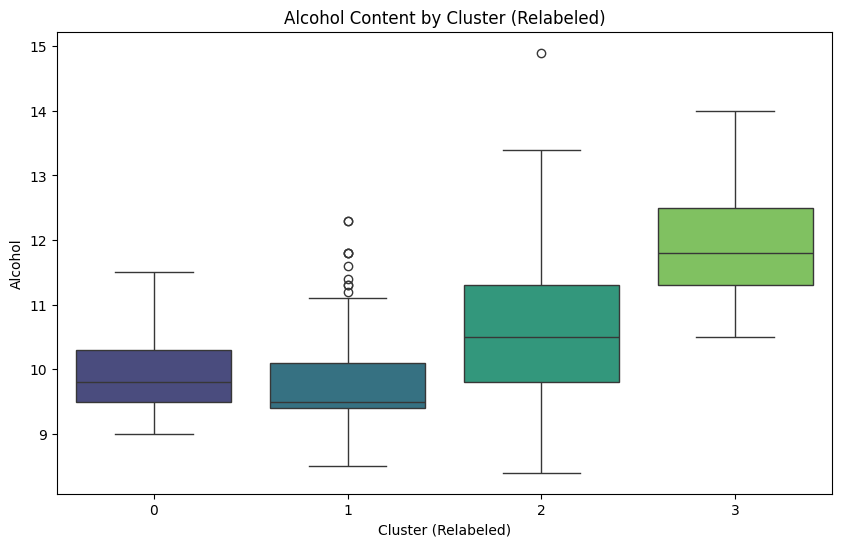

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=wine_df,
    x='kmeans_cl_relab',
    y='alcohol',
    palette='viridis'
)
plt.title('Alcohol Content by Cluster (Relabeled)')
plt.xlabel('Cluster (Relabeled)')
plt.ylabel('Alcohol')
plt.show()

### Alcohol Content by Cluster (Relabeled)

The boxplot shows how alcohol content varies across the four relabeled clusters. Cluster 3 has the highest median alcohol level, followed by Cluster 2, Cluster 0, and Cluster 1. This pattern aligns with the earlier quality-based relabeling, where Cluster 3 represents the highest-quality wines. The spread within Cluster 3 is relatively tight, suggesting consistent alcohol levels among high-quality wines. Cluster 1, which corresponds to low-quality wines, shows the lowest median alcohol content and several high outliers, indicating occasional exceptions but generally lower alcohol levels. Overall, alcohol appears to be positively associated with wine quality in this dataset.

## Boxplots for all features in a loop




/tmp/ipython-input-3284188123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


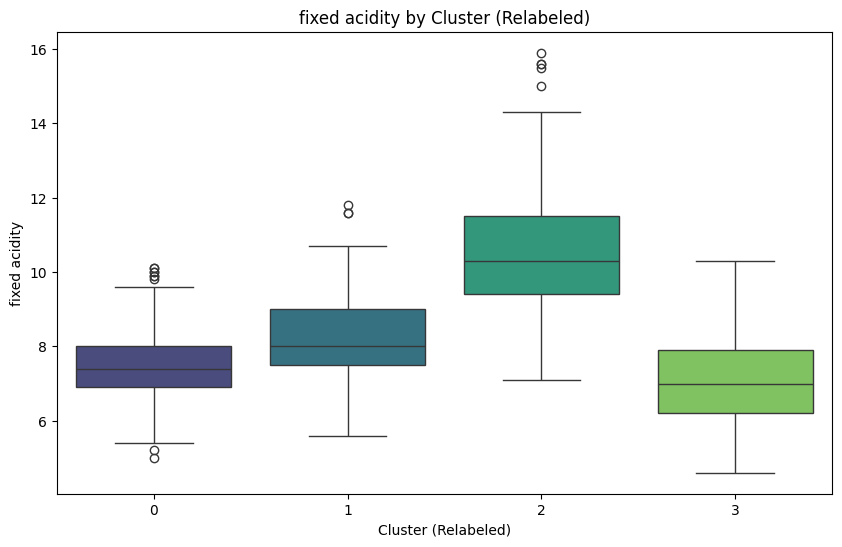

/tmp/ipython-input-3284188123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


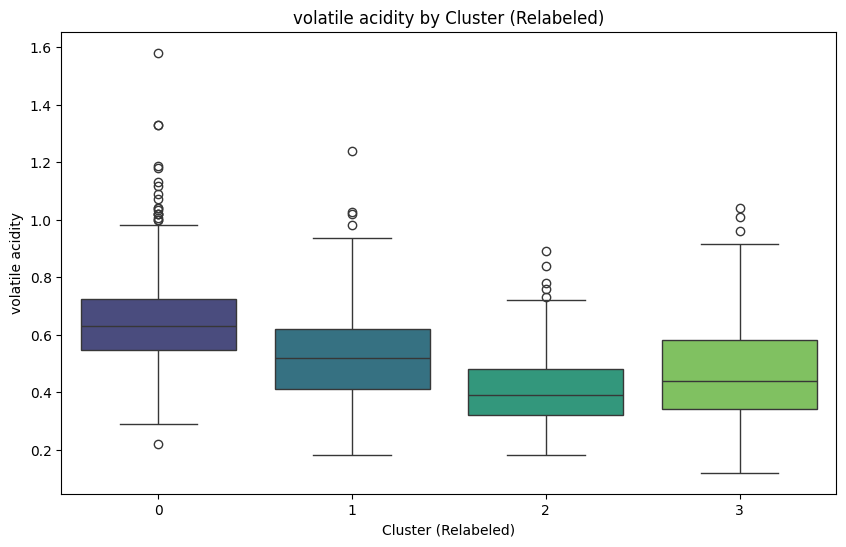

/tmp/ipython-input-3284188123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


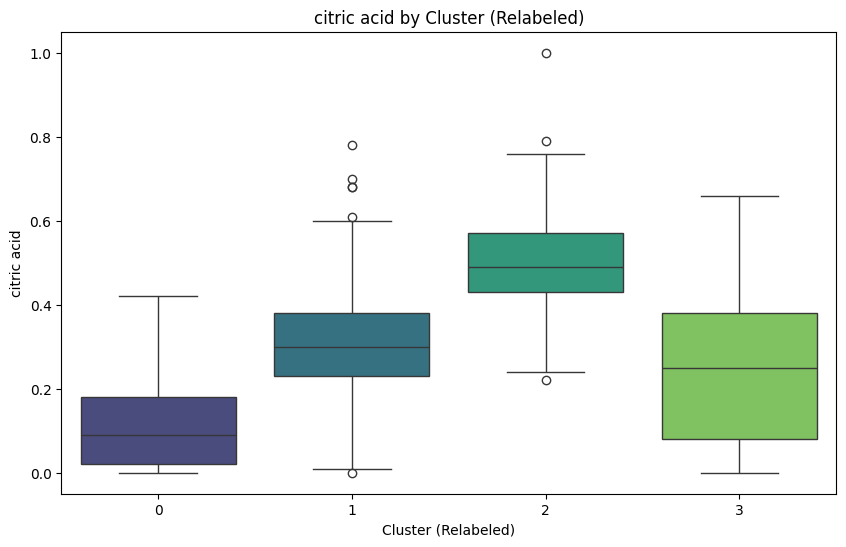

/tmp/ipython-input-3284188123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


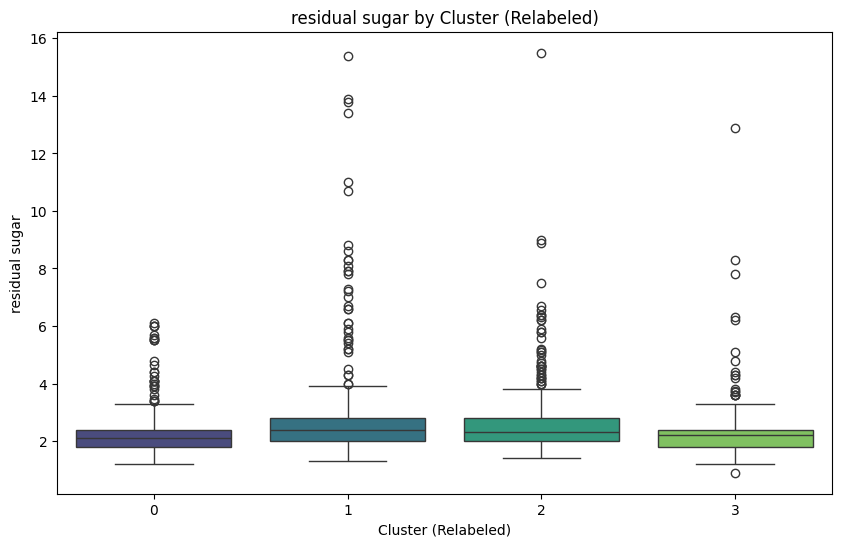

/tmp/ipython-input-3284188123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


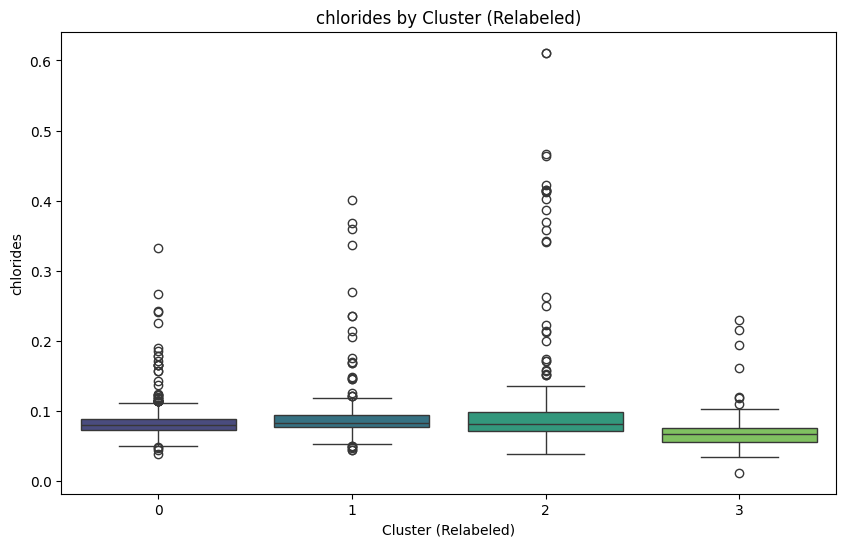

/tmp/ipython-input-3284188123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


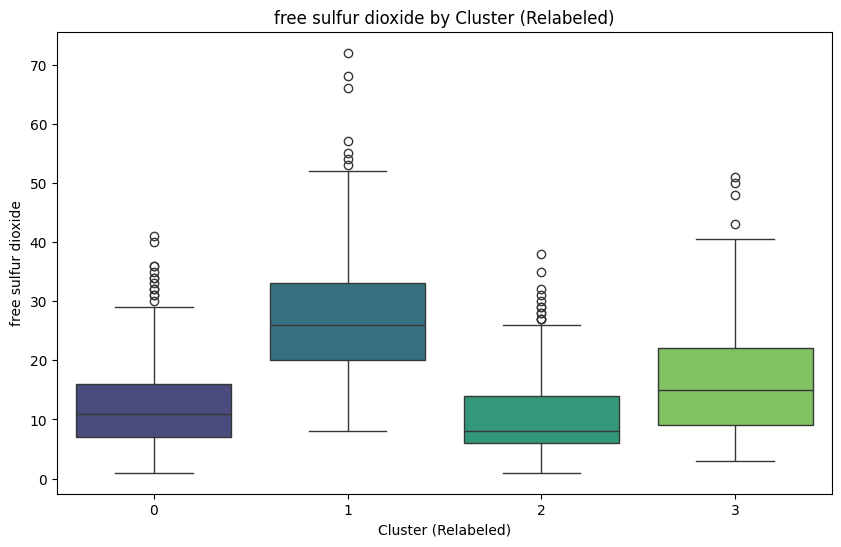

/tmp/ipython-input-3284188123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


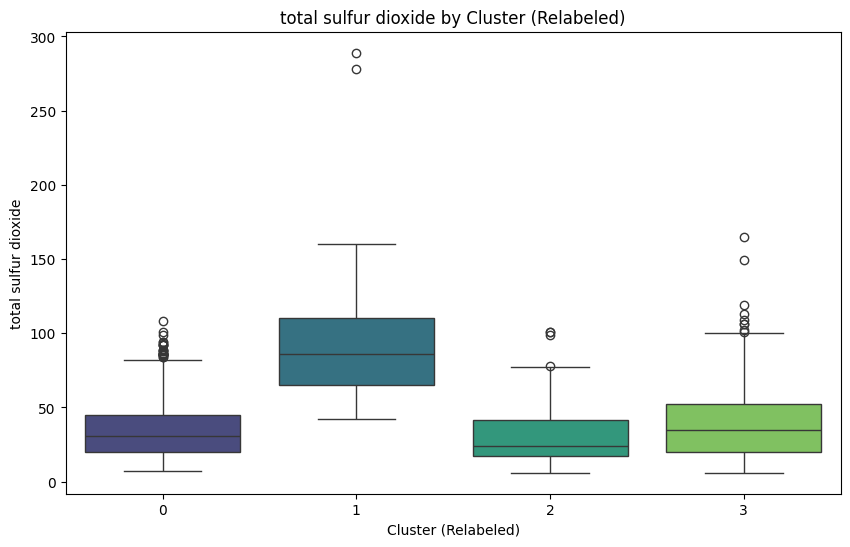

/tmp/ipython-input-3284188123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


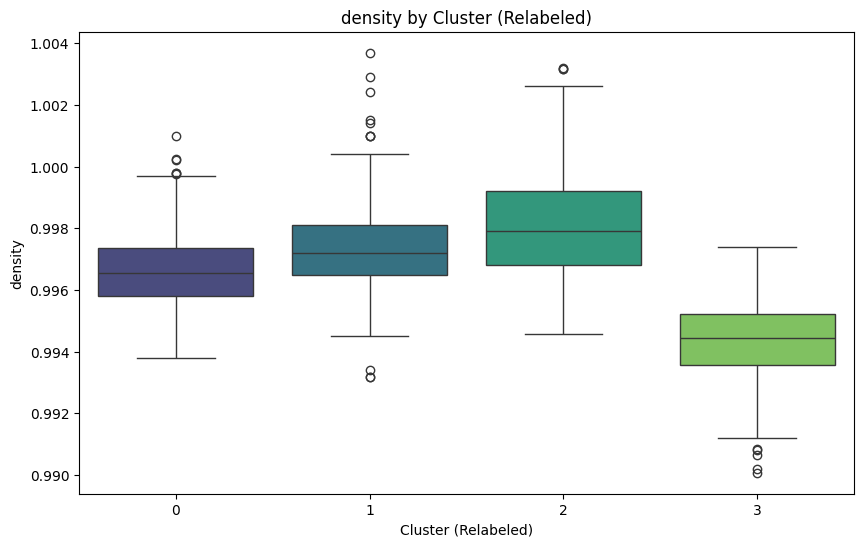

/tmp/ipython-input-3284188123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


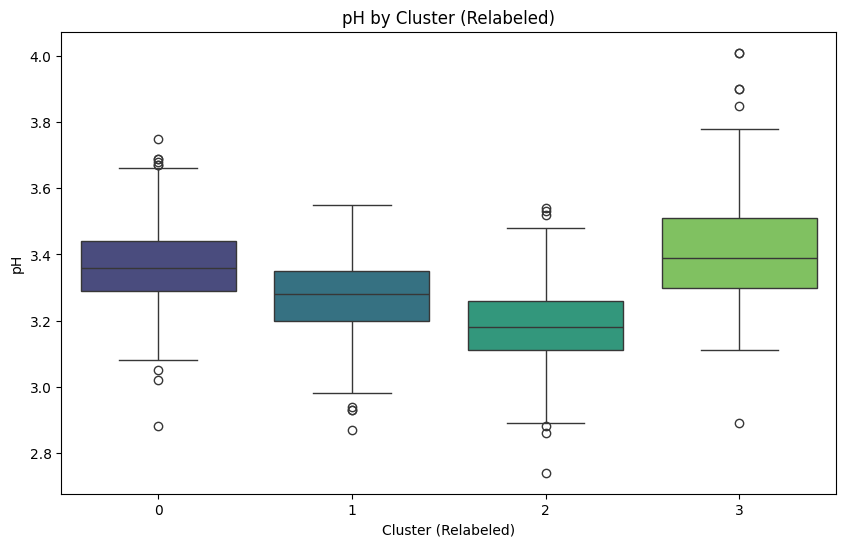

/tmp/ipython-input-3284188123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


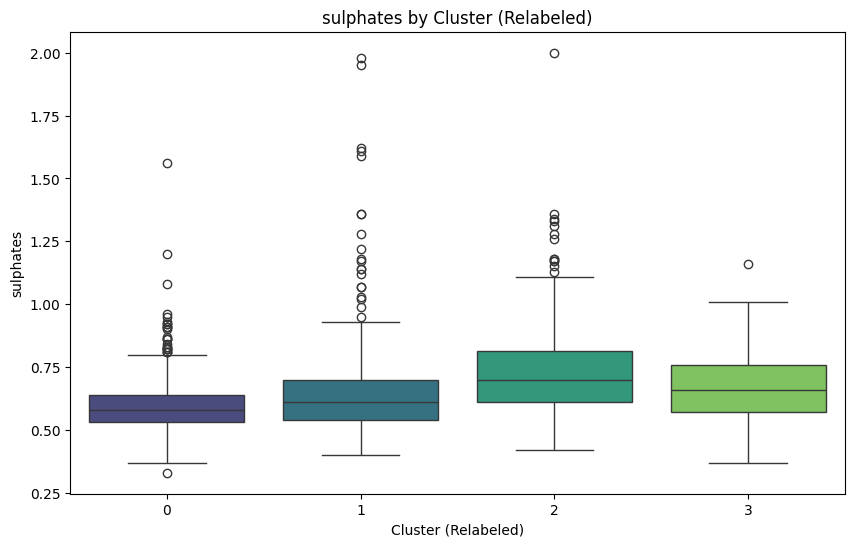

/tmp/ipython-input-3284188123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


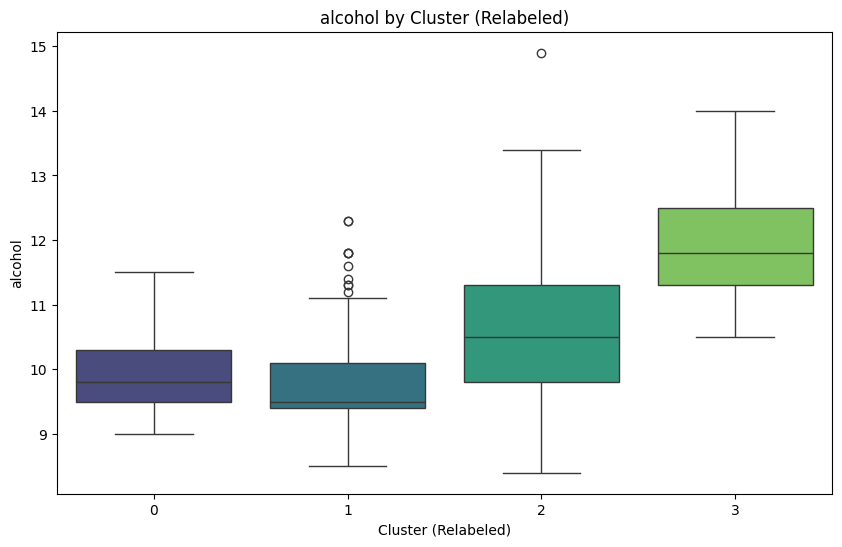

In [ ]:
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
            'density', 'pH', 'sulphates', 'alcohol']

for col in features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=wine_df,
        x='kmeans_cl_relab',
        y=col,
        palette='viridis'
    )
    plt.title(f'{col} by Cluster (Relabeled)')
    plt.xlabel('Cluster (Relabeled)')
    plt.ylabel(col)
    plt.show()

### Fixed Acidity by Cluster (Relabeled)

The boxplot shows how fixed acidity varies across the four relabeled clusters. Cluster 2 has the highest median fixed acidity, followed by Cluster 1 and Cluster 0. Cluster 3, which represents the highest-quality wines, has the lowest median fixed acidity and a tighter distribution. This suggests that lower fixed acidity may be associated with better wine quality in this dataset. Clusters 0 and 1 show wider spreads and more outliers, indicating greater variability in acidity among lower-quality wines. Overall, fixed acidity appears to be inversely related to wine quality across the clusters.

### Volatile Acidity by Cluster (Relabeled)

The boxplot reveals a clear inverse relationship between volatile acidity and wine quality. Cluster 0, which represents the lowest-quality wines, has the highest median volatile acidity and the widest spread, including several high outliers. In contrast, Cluster 2 shows the lowest median volatile acidity, followed by Clusters 3 and 1. Cluster 3, which contains the highest-quality wines, has a relatively low and tightly distributed volatile acidity level. This pattern suggests that lower volatile acidity is associated with better wine quality in this dataset, consistent with known enological principles.

### Citric Acid by Cluster (Relabeled)

The boxplot shows that citric acid levels vary meaningfully across the relabeled clusters. Cluster 2 has the highest median citric acid concentration, followed by Cluster 1 and Cluster 3. Cluster 0, which represents the lowest-quality wines, has the lowest median citric acid and a wider spread. Interestingly, Cluster 3 (highest quality) does not have the highest citric acid, suggesting that while citric acid contributes to wine structure and freshness, it may not be a dominant factor in determining quality in this dataset. The relatively tight distribution in Cluster 3 also suggests more consistency among high-quality wines.

### Residual Sugar by Cluster (Relabeled)

The boxplot shows that residual sugar levels vary across clusters but do not follow a simple linear relationship with wine quality. Cluster 2 has the highest median residual sugar and a wide spread, including several high outliers. Cluster 0 also shows elevated sugar levels, while Clusters 1 and 3 have lower medians and tighter distributions. Interestingly, Cluster 3 — the highest-quality group — has one of the lowest median sugar levels, suggesting that lower residual sugar may be associated with better wine quality in this dataset. However, the variability across clusters indicates that residual sugar alone may not be a strong predictor of quality.

### Chlorides by Cluster (Relabeled)

The boxplot shows that chloride concentration tends to be higher in lower-quality clusters. Cluster 0, which represents the lowest-quality wines, has the highest median chloride level and a wider spread, including several high outliers. Cluster 1 also shows elevated chloride levels. In contrast, Cluster 3 — the highest-quality group — has the lowest median chloride concentration and a tighter distribution. This pattern suggests that lower chloride levels may be associated with better wine quality in this dataset, consistent with the idea that excessive chlorides can negatively affect taste and stability.

### Free Sulfur Dioxide by Cluster (Relabeled)

The boxplot shows that free sulfur dioxide levels vary widely across clusters, with no direct correlation to wine quality. Cluster 1 has the highest median and the widest spread, including several high outliers. Cluster 2 has the lowest median level, while Clusters 0 and 3 fall in between. Interestingly, Cluster 3 — the highest-quality group — does not have the lowest sulfur dioxide levels, suggesting that this feature may not be a strong determinant of quality in this dataset. The variability across clusters indicates that free sulfur dioxide may play a more nuanced role, potentially related to preservation rather than sensory quality.

### Total Sulfur Dioxide by Cluster (Relabeled)

The boxplot shows that total sulfur dioxide levels vary significantly across clusters, with Cluster 1 having the highest median and widest range. This cluster also includes several high outliers, indicating greater variability in sulfur dioxide concentration among lower-quality wines. Cluster 2 has the lowest median level, while Clusters 0 and 3 fall in between. Interestingly, Cluster 3 — the highest-quality group — does not have the lowest sulfur dioxide levels, suggesting that total sulfur dioxide may not be a strong predictor of wine quality in this dataset. Its role may be more related to preservation and microbial stability than to sensory characteristics.

### Density by Cluster (Relabeled)

The boxplot shows a clear inverse relationship between wine density and quality. Cluster 2 has the highest median density, followed by Clusters 1 and 0. Cluster 3 — the highest-quality group — has the lowest median density and a tight distribution. This pattern suggests that lower density is associated with better wine quality in this dataset. Since density is influenced by sugar and alcohol content, this finding aligns with earlier observations: Cluster 3 has higher alcohol and lower residual sugar, contributing to its lower density and higher perceived quality.

### pH by Cluster (Relabeled)

The boxplot shows that pH levels are relatively consistent across clusters, with only subtle differences. Cluster 3 — the highest-quality group — has a slightly lower median pH, while Cluster 2 shows the highest. Clusters 0 and 1 fall in between. The distributions are fairly tight, and all clusters show similar variability. This suggests that pH may not be a strong differentiator of wine quality in this dataset. While pH influences acidity perception and microbial stability, its impact on quality appears limited compared to features like alcohol, volatile acidity, or density.

### Sulphates by Cluster (Relabeled)

The boxplot shows that sulphate concentration is positively associated with wine quality in this dataset. Cluster 3 — the highest-quality group — has the highest median sulphates level and a relatively tight distribution. Cluster 0, which represents the lowest-quality wines, has the lowest median and a wider spread. Clusters 1 and 2 fall in between. Sulphates contribute to microbial stability and can enhance flavor complexity, which may explain their higher levels in better-quality wines. This feature reinforces the separation between high- and low-quality clusters.

The above interpretations cover all physicochemical features except alcohol, which was discussed earlier.

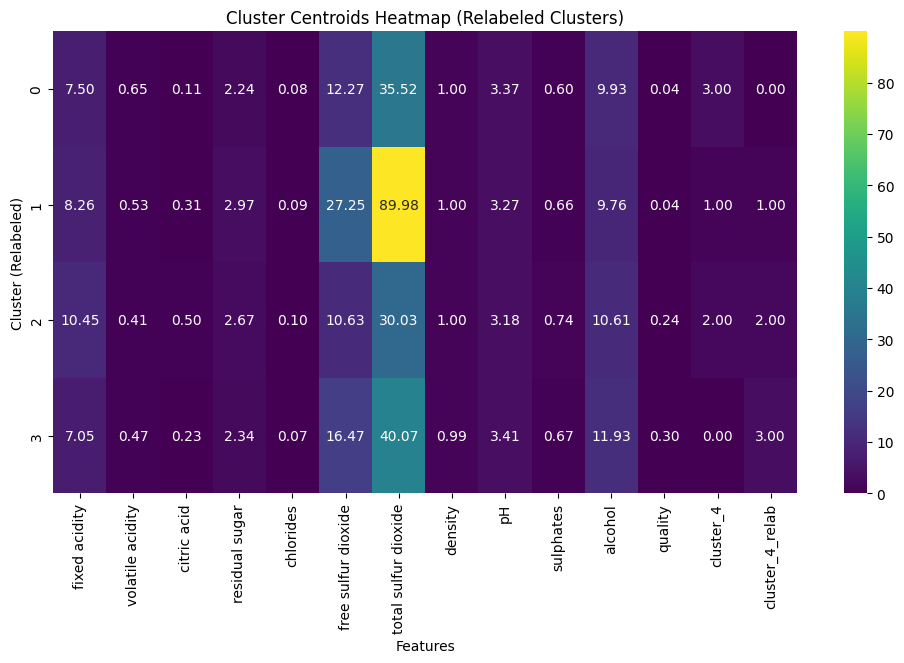

In [ ]:
# Compute cluster centroids on scaled features

centroids = wine_df.groupby('kmeans_cl_relab').mean()


# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(centroids, annot=True, cmap='viridis', fmt=".2f")
plt.title("Cluster Centroids Heatmap (Relabeled Clusters)")
plt.xlabel("Features")
plt.ylabel("Cluster (Relabeled)")
plt.show()

### Cluster Centroid Heatmap (Relabeled)

The heatmap summarizes how each relabeled cluster differs across all features. Cluster 3, which represents the highest-quality wines, shows the highest alcohol (11.93), lowest density (0.99), and relatively high sulphates (0.67), along with low volatile acidity (0.47) and chlorides (0.07). These characteristics align with favorable wine profiles. Cluster 0, the lowest-quality group, has the lowest alcohol (9.93), highest volatile acidity (0.65), and elevated chlorides (0.08), reinforcing its weaker chemical profile.

Cluster 2 shows the highest fixed acidity (10.45) and citric acid (0.50), with moderate alcohol (10.61) and quality (0.24), suggesting a mid-tier wine profile. Cluster 1 stands out for its extremely high total sulfur dioxide (89.98) and elevated residual sugar (2.97), which may contribute to its lower quality despite moderate alcohol and sulphates.

Overall, the heatmap reinforces the patterns observed in the boxplots and highlights alcohol, volatile acidity, chlorides, and sulphates as key features distinguishing high- and low-quality wines.

### Summary of Cluster Interpretation

Overall, the clusters represent distinct wine types that differ systematically in quality. The highest-quality cluster (Cluster 3) is characterized by higher alcohol and sulphates and lower density, volatile acidity, and chlorides. The lowest-quality cluster (Cluster 0) shows the opposite pattern, with higher volatile acidity and chlorides and lower alcohol. The remaining clusters (1 and 2) represent intermediate profiles. These patterns suggest that alcohol, volatile acidity, chlorides, sulphates, and density are key drivers of perceived wine quality in this dataset.